In [2]:
import numpy as np
import matplotlib.pyplot as plt
import jax.numpy as jnp
import jax
from functools import partial
from jax import random
plt.rcParams.update({'font.size': 12})
import matplotlib
matplotlib.rcParams['pdf.fonttype']=42

def gett_all(ijlm, A):
    i, j, l, m = list(ijlm)
    pexp = i+'a,'+j+'a,'+l+'b,'+m+'b->'
    qexp = i+'a,'+j+'a,'+l+'a,'+m+'a->'
    pval = jnp.einsum(pexp, A, A, A, A)
    pqval = pval - jnp.einsum(qexp, A, A, A, A)
    return pval,pqval

@partial(jax.jit, static_argnames=['P','Q'])
def getest_all0(Xs1,Xs2,P,Q,M=jnp.inf,F=jnp.inf):
    #P=jnp.shape(Xs1)[0]
    #Q=jnp.shape(Xs1)[1]
    #Xs1=Xs1_o-jnp.sum(Xs1_o,axis=0)/P
    #Xs2=Xs2_o-jnp.sum(Xs2_o,axis=0)/P

    Phr=(P-1)/(M-1)
    Qhr=(Q-1)/(F-1)
    
    if P<Q:
        Kv=1/Q*jnp.matmul(Xs1,Xs2.T)
        nTrKs_min2=jnp.sum(jnp.diag(jnp.linalg.matrix_power(Kv,2)/P))/P
        #nTrKs_min2=jnp.mean(jnp.square(1/Q*jnp.matmul(Xs1,Xs2.T)))
    else:
        Kv=1/P*jnp.matmul(Xs1.T,Xs2)
        nTrKs_min2=jnp.sum(jnp.diag(jnp.linalg.matrix_power(Kv,2)/Q))/Q
        #nTrKs_min2=jnp.mean(jnp.square(1/P*jnp.matmul(Xs1.T,Xs2)))
            
    Term2=-(1-Phr)/P * jnp.sum(jnp.square(jnp.sum(Xs1*Xs2,axis=1)/Q ))/P
    Term3=-(1-Qhr)/Q * jnp.sum(jnp.square(jnp.sum(Xs1*Xs2,axis=0)/P ))/Q
    Term4=((1-Phr)*(1-Qhr))/(P*Q) * jnp.sum(jnp.power(Xs1*Xs2,2))/(P*Q)
        
    v =  Term2 + Term3 + Term4
    
    nsTrKs = jnp.square(jnp.sum(Xs1*Xs2)/(P*Q))
    
    # if M and F are infinite, or even if M and F are finite:
    numer =  (nsTrKs +v)
    denom =  (nTrKs_min2 +v)

    naive=[nsTrKs, nTrKs_min2]
    row_exp=[nsTrKs+Term2,  nTrKs_min2+Term2]
    col_exp=[nsTrKs+Term3,  nTrKs_min2+Term3]
    double_exp=[numer, denom]
        
    return naive, row_exp, col_exp, double_exp
    
@partial(jax.jit, static_argnames=['P','Q'])
def getest_all(A,P,Q):
    nf = jnp.sqrt(P)*jnp.sqrt(Q)
    # Wrap *all* the following in a single shared_intermediates context
    #with shared_intermediates():
    t1,t1d = gett_all('ijji', A/nf)
    t2,t2d = gett_all('iiii', A/nf)
    t3,t3d = gett_all('ijjj', A/nf)
    #t4,t4d = gett_all('iiij', A/nf)#<
    t5,t5d = gett_all('ijjl', A/nf)
    t6,t6d = gett_all('iijj', A/nf)
    t7,t7d = gett_all('iijl', A/nf)
    #t8,t8d = gett_all('ijll', A/nf)#<
    t9,t9d = gett_all('ijlm', A/nf)

    f1 = P / (P - 2)
    f2 = 2 / (P - 2)
    f3 = (1/(P-1))*(1/(P-2))

    denom_n = t1 - 2/P * t5 + (1/P)**2 * t9
    denom_s = P/(P-3) * (
        t1
        - f1 * t2
        + f2 * (2*t3 - t5)
        + f3 * (t6 - 2*t7 + t9)
    )
    denom_d = (P/(P-3))*(Q/(Q-1)) * (
        t1d
        - f1 * t2d
        + f2 * (2*t3d - t5d)
        + f3 * (t6d - 2*t7d + t9d)
    )

    numer_n = t6 - 2/P * t7 + (1/P)**2 * t9
    numer_s = P/(P-3) * (
        t6 
        - 2/(P-1) * t7 
        + 1/(P-2) * (4*t3 - P*t2) 
        + f3 * (t9 - 4*t5 + 2*t1 - t6) 
    )
    numer_d = (P/(P-3))*(Q/(Q-1))*(
        t6d 
        - 2/(P-1) * t7d 
        + 1/(P-2) * (4*t3d - P*t2d) 
        + f3 * (t9d - 4*t5d + 2*t1d - t6d) 
    )

    numer_s_col = t6d - 2/P * t7d + (1/P)**2 * t9d
    denom_s_col = t1d - 2/P * t5d + (1/P)**2 * t9d
    
    
    naive=[numer_n, denom_n]
    row_exp=[numer_s,  denom_s]
    col_exp=[numer_s_col, denom_s_col]
    double_exp=[numer_d, denom_d]
    
    
    return naive, row_exp, col_exp, double_exp
    

In [3]:
d=50
alpha=0#1.2

P=200
Qs=np.power(10,np.linspace(np.log10(10),np.log10(1000),10)).astype(int)
#Q=12

dia=jnp.power(jnp.arange(d)+1,-alpha)
M=jnp.diag(jnp.sqrt(dia))

gamma=jnp.square(jnp.sum(dia))/jnp.sum(jnp.square(dia))
print(gamma)

# Random seed initialization
key = random.PRNGKey(0)

numit=200
anss=[]
for Q in Qs:
    ans=[]
    for i in range(numit):
        # Generate a P x d matrix with normally distributed entries
        key, subkey = jax.random.split(key)
        X = random.normal(key, shape=(P, d))
        key, subkey = jax.random.split(key)
        W = random.normal(key, shape=(d, Q))
        
        Phi=jnp.matmul(jnp.matmul(X,M),W)/d
        #ans.append([getest_all(Phi,P,Q)])
        ans.append([getest_all0(Phi,Phi,P,Q)])
    anss.append(ans)
anss=np.squeeze(np.array(anss))



2025-03-21 17:25:33.148674: W external/xla/xla/service/gpu/nvptx_compiler.cc:836] The NVIDIA driver's CUDA version is 12.4 which is older than the PTX compiler version (12.6.20). Because the driver is older than the PTX compiler version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


50.0


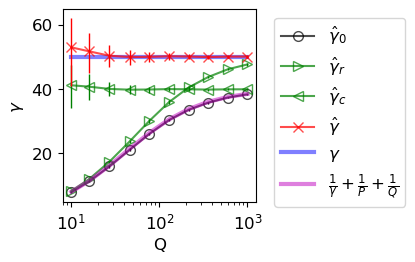

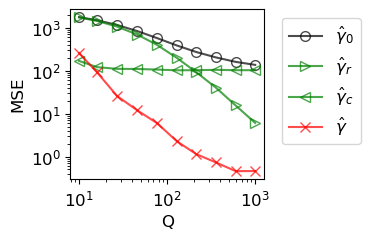

In [4]:
fig,ax=plt.subplots(1,1,figsize=(2.5,2.5))

fig2,ax2=plt.subplots(1,1,figsize=(2.5,2.2))

ms=7

alpha=0.7

xoi=Qs

ls='-'
lw=1.5

colorvs=['k','g','g','r']
markers=['o','>','<','x']
labels=[r'$\hat{\gamma}_0$', r'$\hat{\gamma}_r$', r'$\hat{\gamma}_c$',r'$\hat{\gamma}$',r'$\hat{\gamma}$']
for i,(colorv,marker,label) in enumerate(zip(colorvs,markers,labels)):
    denom=anss[:,:,i,1]
    numer=anss[:,:,i,0]

    qoi=numer/denom #(num_so_Q_it/np.sqrt(de2_so_a_Q_it*de2_so_b_Q_it))[:,:,i,1]
    
    yval=np.nanmedian(qoi,axis=1)
    lower_error=np.nanquantile(qoi,axis=1,q=0.25)
    upper_error=np.nanquantile(qoi,axis=1,q=0.75)
    asymmetric_error = [yval-lower_error, upper_error-yval]
    ax.errorbar(xoi, yval, yerr=asymmetric_error,c=colorv,marker='',ls='',alpha=1,lw=1,zorder=0)#, fmt='o')
    yval=np.nanmean(qoi,axis=1)
    ax.plot(xoi, yval,c=colorv,marker=marker,ls=ls,alpha=alpha,ms=ms,lw=lw,zorder=0,fillstyle='none',label=label)#, fmt='o')

    ax2.plot(xoi, np.mean(np.square(gamma-qoi),axis=1),c=colorv,marker=marker,ls=ls,alpha=alpha,ms=ms,lw=lw,zorder=0,fillstyle='none',label=label )
    #ax.plot(xoi, np.mean(numer,axis=-1)/np.mean(denom,axis=-1),c=colorv)
ax.plot(xoi,xoi*0+gamma,c='b',label=r'$\gamma$',zorder=-10,alpha=0.5,lw=3)
ax.plot(xoi,1/(1/xoi+1/P+1/gamma),c='m',ls='-',alpha=0.5,lw=3,label=r'$\frac{1}{\gamma} + \frac{1}{P} + \frac{1}{Q}$')
#ax.legend()
ax.legend(loc='upper left', bbox_to_anchor=(1.05, 1))
ax.set_xlabel('Q')
ax.set_xscale('log')
ax.set_ylabel(r'$\gamma$')



fig.savefig("linear_dim.pdf", bbox_inches='tight')

ax2.legend(loc='upper left', bbox_to_anchor=(1.05, 1))
ax2.set_ylabel('MSE')
ax2.set_xlabel('Q')
ax2.set_xscale('log')
ax2.set_yscale('log')

fig2.savefig("linear_dim_mse.pdf", bbox_inches='tight')
